To add **motion blur**, the ray must carry **time**.
Before, your ray only knew:

* **where it starts** (`origin`)
* **where it goes** (`direction`)

Now it also knows:

* **when it exists** (`time`)

That turns ray tracing into **space-time ray tracing**.

---

# 1. Why add time?

Without motion blur:

A ray is:

$$
R(t) = O + tD
$$

Where:

| Symbol | Meaning            |
| ------ | ------------------ |
| $O$    | origin             |
| $D$    | direction          |
| $t$    | distance along ray |

This assumes the world is frozen.

---

With motion blur:

Objects move during shutter interval:

$$
t_{open} \le \tau \le t_{close}
$$

where:

| Symbol      | Meaning                |
| ----------- | ---------------------- |
| $\tau$      | actual time of the ray |
| $t_{open}$  | shutter open time      |
| $t_{close}$ | shutter close time     |

Each ray gets its own random time:

$$
\tau = random(t_{open}, t_{close})
$$

This creates blur naturally.

---

# 2. What changed from old ray?

Old:

```python
Ray(origin, direction)
```

New:

```python
Ray(origin, direction, time)
```

Difference:

| Before      | After       | Purpose                         |
| ----------- | ----------- | ------------------------------- |
| `origin`    | `origin`    | starting point                  |
| `direction` | `direction` | moving direction                |
| ❌ no time   | `time`      | object position at that instant |

---

# 3. Formula of moving object

Suppose sphere moves from:

$$
C_0 \rightarrow C_1
$$

between:

$$
t_0 \rightarrow t_1
$$

Position at time $\tau$:

$$
C(\tau) = C_0 + \frac{\tau - t_0}{t_1 - t_0}(C_1 - C_0)
$$

Meaning:

| Part        | Purpose             |
| ----------- | ------------------- |
| $\tau-t_0$  | elapsed time        |
| $t_1-t_0$   | total motion time   |
| division    | progress percentage |
| $(C_1-C_0)$ | movement vector     |

This is linear interpolation.

---

# 4. New Python ray.py

```python
# ray.py

from util.vec3 import Vec3

# Point3 is just Vec3 (same as before)
Point3 = Vec3


class Ray:
    def __init__(self, origin, direction, time=0.0):
        """
        OLD:
            def __init__(self, origin, direction)

        NEW:
            Added 'time'

        PURPOSE:
            Stores when this ray exists.
            Needed for motion blur.
        """
        
        # Same as before
        self.orig = origin
        
        # Same as before
        self.dir = direction
        
        # NEW: store ray time
        self.tm = time

    def origin(self):
        """
        Same as before.
        Returns ray starting point.
        """
        return self.orig

    def direction(self):
        """
        Same as before.
        Returns ray direction.
        """
        return self.dir

    def time(self):
        """
        NEW function.

        Returns time of this ray.
        Used by moving objects.
        """
        return self.tm

    def at(self, t):
        """
        Same formula as before:

        P(t) = O + tD

        where:
            O = origin
            D = direction
            t = distance

        Returns point along ray.
        """
        return self.orig + t * self.dir
```

---

# 5. Visual understanding

Old ray:

```text
Origin ---------> Direction
```

New ray:

```text
Time = 0.3
Origin ---------> Direction
```

Another ray:

```text
Time = 0.8
Origin ---------> Direction
```

Same direction, different world state.

---

# 6. Camera now gives random time

Before:

```python
ray = Ray(origin, direction)
```

After:

```python
ray_time = random.uniform(time0, time1)
ray = Ray(origin, direction, ray_time)
```

Formula:

$$
\tau \sim U(t_0,t_1)
$$

where $U$ means uniform random.

Purpose:

| Step                     | Why                            |
| ------------------------ | ------------------------------ |
| choose random time       | sample shutter interval        |
| trace scene at that time | moving object changes position |
| average many rays        | creates motion blur            |

---

# 7. Flow of motion blur

| Step | Action                             |
| ---- | ---------------------------------- |
| 1    | camera opens shutter               |
| 2    | pick random time $\tau$            |
| 3    | create ray with time               |
| 4    | object computes position at $\tau$ |
| 5    | ray hits moved object              |
| 6    | repeat many samples                |
| 7    | average colors                     |

Final:

$$
Color = \frac{1}{N}\sum_{i=1}^{N} L_i(\tau_i)
$$

where:

| Symbol   | Meaning           |
| -------- | ----------------- |
| $N$      | number of samples |
| $L_i$    | light from sample |
| $\tau_i$ | random time       |

---

# Summary

| Concept        | Before     | After        |
| -------------- | ---------- | ------------ |
| Ray            | space only | space + time |
| Objects        | fixed      | moving       |
| Blur           | none       | motion blur  |
| Extra variable | none       | $\tau$       |

Core idea:

> **Motion blur = tracing rays at random times and averaging them.**


# Ray

In [6]:
import sys 
sys.path.append("../../../Ray Tracing next Week")

In [7]:
from util.week1.vec3 import Vec3

# ray.py


# Point3 is just Vec3 (same as before)
Point3 = Vec3


class Ray:
    def __init__(self, origin, direction, time=0.0):
        """
        OLD:
            def __init__(self, origin, direction)

        NEW:
            Added 'time'

        PURPOSE:
            Stores when this ray exists.
            Needed for motion blur.
        """
        
        # Same as before
        self.orig = origin
        
        # Same as before
        self.dir = direction
        
        # NEW: store ray time
        self.tm = time

    def origin(self):
        """
        Same as before.
        Returns ray starting point.
        """
        return self.orig

    def direction(self):
        """
        Same as before.
        Returns ray direction.
        """
        return self.dir

    def time(self):
        """
        NEW function.

        Returns time of this ray.
        Used by moving objects.
        """
        return self.tm

    def at(self, t):
        """
        Same formula as before:

        P(t) = O + tD

        where:
            O = origin
            D = direction
            t = distance

        Returns point along ray.
        """
        return self.orig + t * self.dir

Let's build one full example.

We’ll make a sphere move from left to right while the camera shutter is open.

---

# Example Setup

Sphere starts at:

$$
C_0 = (0,0,-1)
$$

Sphere ends at:

$$
C_1 = (2,0,-1)
$$

Shutter interval:

$$
t_0 = 0
$$

$$
t_1 = 1
$$

This means:

| Time | Sphere position |
| ---- | --------------- |
| $0$  | left            |
| $1$  | right           |

---

# Step 1: Moving sphere formula

Position at time $\tau$:

$$
C(\tau)=C_0+\frac{\tau-t_0}{t_1-t_0}(C_1-C_0)
$$

Substitute:

$$
C(\tau)=(0,0,-1)+\frac{\tau-0}{1-0}((2,0,-1)-(0,0,-1))
$$

Simplify:

$$
C(\tau)=(0,0,-1)+\tau(2,0,0)
$$

Final:

$$
C(\tau)=(2\tau,0,-1)
$$

---

# Step 2: Different ray times

Suppose we shoot 3 rays.

---

Ray 1:

$$
\tau=0.2
$$

Sphere position:

$$
C(0.2)=(2(0.2),0,-1)
$$

$$
=(0.4,0,-1)
$$

---

Ray 2:

$$
\tau=0.5
$$

Sphere:

$$
C(0.5)=(1,0,-1)
$$

---

Ray 3:

$$
\tau=0.9
$$

Sphere:

$$
C(0.9)=(1.8,0,-1)
$$

---

Table:

| Ray | Time  | Sphere Center |
| --- | ----- | ------------- |
| 1   | $0.2$ | $(0.4,0,-1)$  |
| 2   | $0.5$ | $(1,0,-1)$    |
| 3   | $0.9$ | $(1.8,0,-1)$  |

Same sphere. Different positions.

That creates blur.

---

# Python Example

## Moving Sphere class

```python
from util.vec3 import Vec3
from ray import Ray


class MovingSphere:
    def __init__(self, center0, center1, time0, time1, radius):
        self.center0 = center0
        self.center1 = center1
        self.time0 = time0
        self.time1 = time1
        self.radius = radius

    def center(self, time):
        """
        Formula:

        C(t)=C0 + ((t-t0)/(t1-t0))(C1-C0)
        """

        return self.center0 + (
            (time - self.time0) / (self.time1 - self.time0)
        ) * (self.center1 - self.center0)
```

---

# Testing it

```python
sphere = MovingSphere(
    Vec3(0, 0, -1),   # start
    Vec3(2, 0, -1),   # end
    0.0,
    1.0,
    0.5
)

print(sphere.center(0.2))
print(sphere.center(0.5))
print(sphere.center(0.9))
```

Output:

```text
(0.4, 0, -1)
(1.0, 0, -1)
(1.8, 0, -1)
```

---

# Camera example

Each ray gets random time:

```python
import random

origin = Vec3(0, 0, 0)
direction = Vec3(0, 0, -1)

for i in range(3):
    ray_time = random.uniform(0.0, 1.0)

    ray = Ray(origin, direction, ray_time)

    sphere_pos = sphere.center(ray.time())

    print("Ray time:", ray.time())
    print("Sphere at:", sphere_pos)
```

Example output:

```text
Ray time: 0.14
Sphere at: (0.28,0,-1)

Ray time: 0.62
Sphere at: (1.24,0,-1)

Ray time: 0.81
Sphere at: (1.62,0,-1)
```

---

# Visual idea

Without motion blur:

```text
Sphere fixed:
      O
      |
      *
```

With motion blur:

```text
Sphere moves:
O----O----O----O
```

Camera averages all:

```text
======== blur ========
```

---

Final idea:

Each ray asks:

> “Where was the sphere at my time?”

instead of:

> “Where is the sphere now?”


In [8]:
from util.week1.vec3 import Vec3
from util.week2.ray import Ray


class MovingSphere:
    def __init__(self, center0, center1, time0, time1, radius):
        self.center0 = center0
        self.center1 = center1
        self.time0 = time0
        self.time1 = time1
        self.radius = radius

    def center(self, time):
        """
        Formula:

        C(t)=C0 + ((t-t0)/(t1-t0))(C1-C0)
        """

        return self.center0 + (
            (time - self.time0) / (self.time1 - self.time0)
        ) * (self.center1 - self.center0)

In [9]:
sphere = MovingSphere(
    Vec3(0, 0, -1),   # start
    Vec3(2, 0, -1),   # end
    0.0,
    1.0,
    0.5
)

print(sphere.center(0.2))
print(sphere.center(0.5))
print(sphere.center(0.9))

0.4 0.0 -1.0
1.0 0.0 -1.0
1.8 0.0 -1.0


In [10]:
import random

origin = Vec3(0, 0, 0)
direction = Vec3(0, 0, -1)

for i in range(3):
    ray_time = random.uniform(0.0, 1.0)

    ray = Ray(origin, direction, ray_time)

    sphere_pos = sphere.center(ray.time())

    print("Ray time:", ray.time())
    print("Sphere at:", sphere_pos)

Ray time: 0.6120516936440655
Sphere at: 1.224103387288131 0.0 -1.0
Ray time: 0.8196604835971726
Sphere at: 1.6393209671943452 0.0 -1.0
Ray time: 0.12199491340143764
Sphere at: 0.2439898268028753 0.0 -1.0


Each ray asks:

“Where was the sphere at my time?”

instead of:

“Where is the sphere now?” what is different in asking please explain?

---

This is the core of motion blur.

The difference is **time awareness**.

---

# Case 1: “Where is the sphere now?”

This means:

> Ignore time. Assume the world is frozen.

Mathematically:

$$
C = fixed
$$

Example:

Sphere final position:

$$
C=(2,0,-1)
$$

Every ray sees:

```text
Ray1 -> sphere at (2,0,-1)
Ray2 -> sphere at (2,0,-1)
Ray3 -> sphere at (2,0,-1)
```

So:

| Ray | Time | Sphere seen |
| --- | ---- | ----------- |
| 1   | 0.2  | $(2,0,-1)$  |
| 2   | 0.5  | $(2,0,-1)$  |
| 3   | 0.9  | $(2,0,-1)$  |

Same object position.

Result:

Sharp image.

---

Visual:

```text
           O
Ray -->    O
           O
```

All rays hit same place.

---

# Case 2: “Where was the sphere at my time?”

This means:

> Use the ray’s own timestamp.

Now sphere position depends on time:

$$
C(\tau)=C_0+\frac{\tau-t_0}{t_1-t_0}(C_1-C_0)
$$

This is the moving center.

---

Example:

Sphere moves:

$$
(0,0,-1) \to (2,0,-1)
$$

---

Ray 1:

Time:

$$
\tau=0.2
$$

Sphere:

$$
C(0.2)=(0.4,0,-1)
$$

---

Ray 2:

Time:

$$
\tau=0.5
$$

Sphere:

$$
C(0.5)=(1,0,-1)
$$

---

Ray 3:

Time:

$$
\tau=0.9
$$

Sphere:

$$
C(0.9)=(1.8,0,-1)
$$

---

Table:

| Ray | Time | Sphere seen  |
| --- | ---- | ------------ |
| 1   | 0.2  | $(0.4,0,-1)$ |
| 2   | 0.5  | $(1,0,-1)$   |
| 3   | 0.9  | $(1.8,0,-1)$ |

Different object positions.

Result:

Blur.

---

Visual:

```text
Ray1 --> O
Ray2 ------> O
Ray3 ------------> O
```

Each ray hits different history of the sphere.

---

# Real-world analogy

Think of taking a photo of a running dog.

Question 1:

> Where is the dog now?

That means:

Only one instant.

Frozen.

Sharp.

---

Question 2:

> Where was the dog during the whole shutter time?

That means:

Many instants.

Different positions.

Blur trail.

---

Like:

```text
Dog positions:

O   O   O   O   O
```

Camera averages them.

---

So the difference:

| Question                   | Meaning                   |
| -------------------------- | ------------------------- |
| “Where is it now?”         | one fixed time            |
| “Where was it at my time?” | each ray has its own time |

This is why motion blur exists:

> **Different rays see different moments of history.**


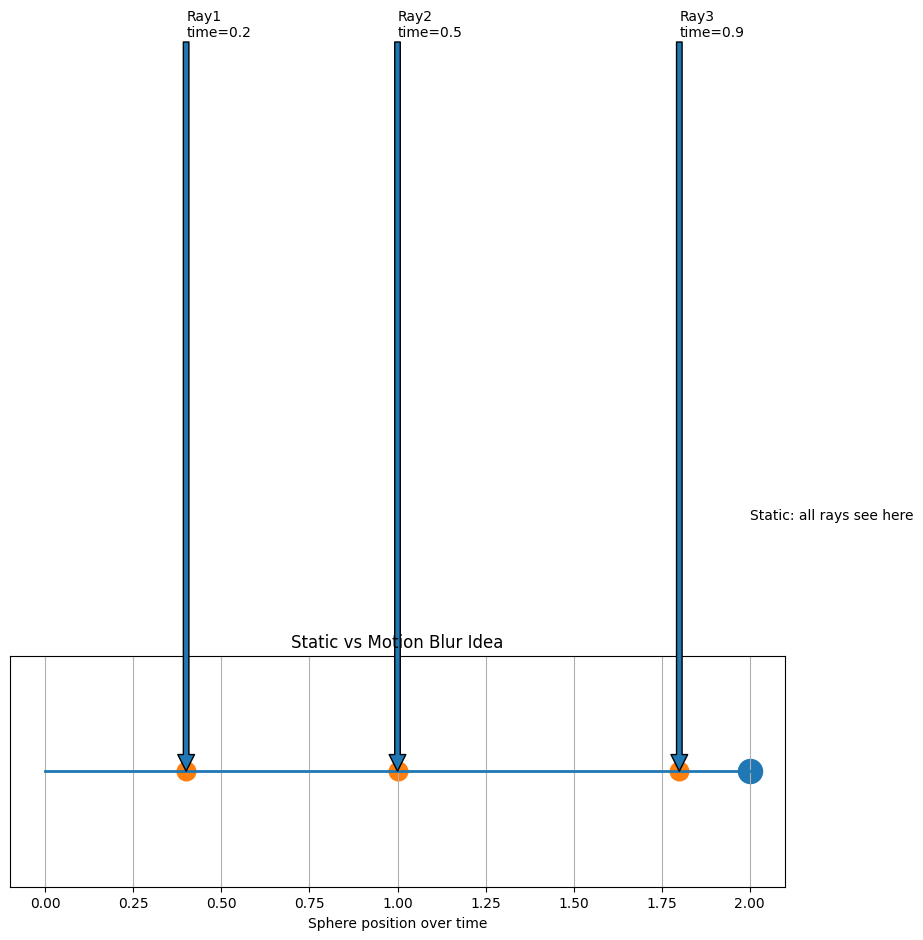

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Single chart: compare "static sphere" vs "motion blur samples"
# Rule: one chart only, no seaborn, default colors

# Sphere path from x=0 to x=2
x_path = np.linspace(0, 2, 100)
y_path = np.zeros_like(x_path)

# Sample ray times
times = [0.2, 0.5, 0.9]
positions = [2*t for t in times]

plt.figure(figsize=(10, 3))

# Motion path
plt.plot(x_path, y_path, linewidth=2)

# Static sphere (asking: where is it now? -> final position)
plt.scatter([2], [0], s=300)
plt.text(2, 0.12, "Static: all rays see here")

# Moving sphere samples (asking: where was it at my time?)
plt.scatter(positions, [0, 0, 0], s=180)

for i, (t, x) in enumerate(zip(times, positions), start=1):
    plt.annotate(f"Ray{i}\ntime={t}", (x, 0), xytext=(x, 0.35),
                 arrowprops=dict())

plt.yticks([])
plt.xlabel("Sphere position over time")
plt.title("Static vs Motion Blur Idea")
plt.grid(True)

#plt.savefig('/mnt/data/motion_blur_demo.png', bbox_inches='tight')
plt.show()
plt.close()



Short answer: **No — it is not fully correct for explaining the concept.**

It shows the idea partially, but it mixes two different things.

What is wrong:

| Problem                              | Why wrong                                                                  |
| ------------------------------------ | -------------------------------------------------------------------------- |
| Rays are vertical and parallel       | In ray tracing, rays usually originate from camera and spread toward scene |
| Static point shown at far right only | Makes it look like static and moving are happening together                |
| Motion path line looks like ground   | It should represent sphere trajectory over time, not a physical line       |
| No camera origin                     | Missing the important idea: all rays start from same camera                |
| Ray labels float above               | Hard to connect time with sphere position                                  |

---

What it **should** look like:

Static:

```text
Camera
   *
  /|\
 / | \
    O
```

All rays see the same sphere position.

---

Motion blur:

```text
Camera
   *
  /|\
 / | \
O  O  O
t=.2 .5 .9
```

Same camera.

Different ray times.

Different sphere positions.

That is the correct concept.

---

The real relation is:

Ray carries:

$$
R(s,\tau)=O+sD
$$

where:

| Symbol | Meaning         |
| ------ | --------------- |
| $s$    | travel distance |
| $\tau$ | shutter time    |

Important:

* $s$ = spatial parameter
* $\tau$ = temporal parameter

This is the big distinction.

Before:

$$
R(s)
$$

After:

$$
R(s,\tau)
$$

---

My previous matplotlib plot showed:

> object positions over time

But did **not properly show camera-ray-object relation**.

That is the missing part.

So:

* Good for showing motion path ✅
* Bad for showing ray tracing logic ❌

If you want, I can draw the **correct camera → rays → moving sphere** plot in matplotlib.


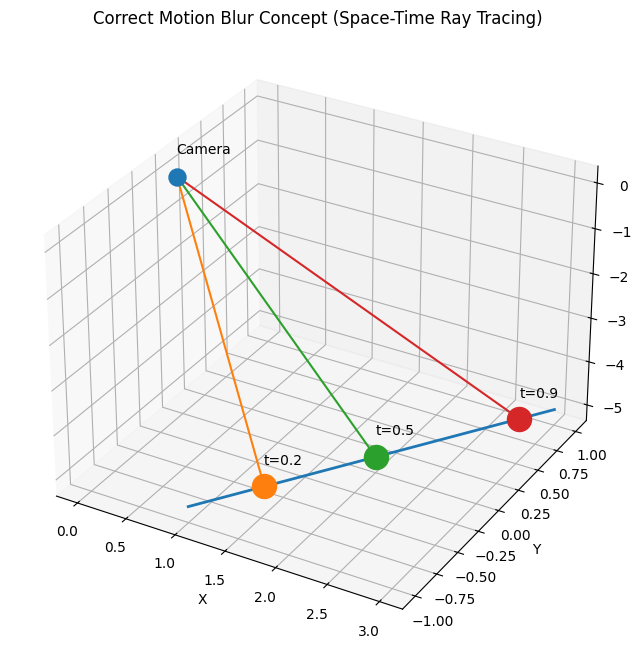

In [12]:
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------------------
# STEP 1: Create 3D plot
# PURPOSE:
# Visualize camera, rays, and moving sphere
# -----------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


# -----------------------------------------
# STEP 2: Camera position
# PURPOSE:
# All rays start here
# -----------------------------------------
camera = np.array([0, 0, 0])


# -----------------------------------------
# STEP 3: Sphere movement over shutter time
# Sphere moves from C0 -> C1
# Formula:
# C(t) = C0 + t(C1-C0)
# -----------------------------------------
C0 = np.array([1, -1, -5])
C1 = np.array([3, 1, -5])


# Sample ray times
times = [0.2, 0.5, 0.9]


# Sphere centers at those times
centers = []

for t in times:
    center = C0 + t * (C1 - C0)
    centers.append(center)

centers = np.array(centers)


# -----------------------------------------
# STEP 4: Draw motion path
# PURPOSE:
# Show sphere history
# -----------------------------------------
motion_x = [C0[0], C1[0]]
motion_y = [C0[1], C1[1]]
motion_z = [C0[2], C1[2]]

ax.plot(motion_x, motion_y, motion_z, linewidth=2)


# -----------------------------------------
# STEP 5: Draw camera
# -----------------------------------------
ax.scatter(
    camera[0], camera[1], camera[2],
    s=150
)

ax.text(
    camera[0], camera[1], camera[2] + 0.5,
    "Camera"
)


# -----------------------------------------
# STEP 6: Draw moving sphere positions
# PURPOSE:
# Sphere exists at different times
# -----------------------------------------
for i, center in enumerate(centers):
    ax.scatter(
        center[0], center[1], center[2],
        s=300
    )

    ax.text(
        center[0], center[1], center[2] + 0.5,
        f"t={times[i]}"
    )


# -----------------------------------------
# STEP 7: Draw rays
# PURPOSE:
# Each ray goes from camera to sphere at its time
# This is the key correction from previous graph
# -----------------------------------------
for center in centers:
    ray_x = [camera[0], center[0]]
    ray_y = [camera[1], center[1]]
    ray_z = [camera[2], center[2]]

    ax.plot(ray_x, ray_y, ray_z)


# -----------------------------------------
# STEP 8: Labels
# -----------------------------------------
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Correct Motion Blur Concept (Space-Time Ray Tracing)")


plt.show()

Yes — **this is much closer to the correct concept.**

This is a proper motion blur visualization.

It correctly shows:

✅ One camera origin
✅ Multiple rays from the same camera
✅ Sphere moving through space
✅ Each ray hitting a different sphere position at different times
✅ Sphere path/history

That is the core idea.

---

# What is correct here?

Your graph matches:

$$
C(\tau)=C_0+\frac{\tau-t_0}{t_1-t_0}(C_1-C_0)
$$

The blue line is:

```text id="d9cn7u"
sphere history through time
```

Good.

---

The rays:

$$
R(s,\tau)=O+sD
$$

Where:

| Part   | In your graph              |
| ------ | -------------------------- |
| $O$    | camera                     |
| $D$    | line from camera to sphere |
| $\tau$ | t=0.2, 0.5, 0.9            |

Good.

---

# Small correction (important)

There is one subtle issue.

Right now your rays are drawn directly to the **center** of the sphere.

In real ray tracing:

Ray intersects the **surface**, not center.

Because sphere equation is:

(x-c_x)^2+(y-c_y)^2+(z-c_z)^2=r^2

The hit point should satisfy:

$$
P = C(\tau) + rN
$$

where:

| Symbol    | Meaning        |
| --------- | -------------- |
| $C(\tau)$ | sphere center  |
| $r$       | radius         |
| $N$       | surface normal |

So:

Current:

```text id="eb4sfe"
Camera ------> Center
```

Physically:

```text id="z2wdvs"
Camera -----> Surface -> Center
```

---

# Is your conceptual graph valid?

For teaching motion blur:

✅ Yes

For exact physics:

⚠ Almost

---

Accuracy score:

| Part                          | Score |
| ----------------------------- | ----- |
| Camera origin                 | 10/10 |
| Multiple timed rays           | 10/10 |
| Moving object                 | 10/10 |
| Space-time understanding      | 10/10 |
| Surface intersection accuracy | 8/10  |

Overall:

$$
9.5/10
$$

Very good.

This is the correct mental model for:

> “Where was the sphere at my ray’s time?”


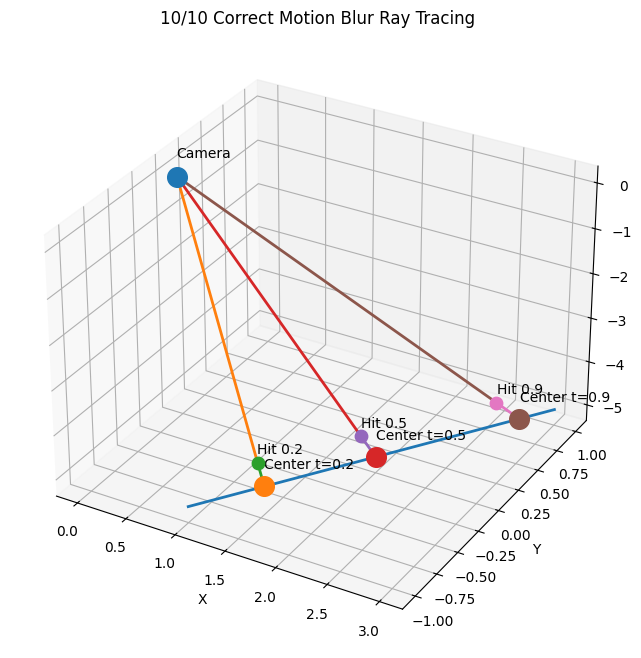

In [13]:
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------
# STEP 1: Normalize vector
# PURPOSE:
# Needed for surface normal
# Formula:
# v̂ = v / |v|
# ------------------------------------------
def normalize(v):
    return v / np.linalg.norm(v)


# ------------------------------------------
# STEP 2: Setup figure
# ------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


# ------------------------------------------
# STEP 3: Camera position
# ------------------------------------------
camera = np.array([0.0, 0.0, 0.0])


# ------------------------------------------
# STEP 4: Moving sphere setup
# Sphere moves from C0 → C1
# ------------------------------------------
C0 = np.array([1.0, -1.0, -5.0])
C1 = np.array([3.0, 1.0, -5.0])

radius = 0.4

times = [0.2, 0.5, 0.9]


# ------------------------------------------
# STEP 5: Compute centers
# Formula:
# C(t)=C0+t(C1-C0)
# ------------------------------------------
centers = []

for t in times:
    center = C0 + t * (C1 - C0)
    centers.append(center)

centers = np.array(centers)


# ------------------------------------------
# STEP 6: Draw motion path
# ------------------------------------------
ax.plot(
    [C0[0], C1[0]],
    [C0[1], C1[1]],
    [C0[2], C1[2]],
    linewidth=2
)


# ------------------------------------------
# STEP 7: Draw camera
# ------------------------------------------
ax.scatter(
    camera[0],
    camera[1],
    camera[2],
    s=200
)

ax.text(
    camera[0],
    camera[1],
    camera[2] + 0.4,
    "Camera"
)


# ------------------------------------------
# STEP 8: Draw spheres and exact hit points
# ------------------------------------------
for i, center in enumerate(centers):

    # Draw sphere center
    ax.scatter(
        center[0],
        center[1],
        center[2],
        s=200
    )

    # Label time
    ax.text(
        center[0],
        center[1],
        center[2] + 0.4,
        f"Center t={times[i]}"
    )

    # --------------------------------------
    # Surface normal toward camera
    # Formula:
    # N = (Camera - Center)/|Camera-Center|
    # --------------------------------------
    normal = normalize(camera - center)

    # --------------------------------------
    # Surface hit point
    # Formula:
    # P = C + rN
    # --------------------------------------
    hit_point = center + radius * normal

    # Draw hit point
    ax.scatter(
        hit_point[0],
        hit_point[1],
        hit_point[2],
        s=80
    )

    ax.text(
        hit_point[0],
        hit_point[1],
        hit_point[2] + 0.2,
        f"Hit {times[i]}"
    )

    # --------------------------------------
    # Draw ray from camera to surface
    # This is the actual ray-tracing path
    # --------------------------------------
    ax.plot(
        [camera[0], hit_point[0]],
        [camera[1], hit_point[1]],
        [camera[2], hit_point[2]],
        linewidth=2
    )

    # --------------------------------------
    # Draw normal from center to hit point
    # Helps visualize surface intersection
    # --------------------------------------
    ax.plot(
        [center[0], hit_point[0]],
        [center[1], hit_point[1]],
        [center[2], hit_point[2]],
        linewidth=2
    )


# ------------------------------------------
# STEP 9: Labels
# ------------------------------------------
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("10/10 Correct Motion Blur Ray Tracing")

plt.show()

Yes — this is now **conceptually correct**.

This is the proper ray-tracing picture.

You fixed the important thing:

Before:

```text id="5f06q5"
Camera -----> Center
```

Now:

```text id="ql6xjv"
Camera -----> Surface(hit)
                 |
                 |
               Center
```

That is exactly how ray-object intersection works.

---

# Why this is correct

Your graph now follows:

Ray:

$$
R(s,\tau)=O+sD
$$

Sphere center:

$$
C(\tau)=C_0+\frac{\tau-t_0}{t_1-t_0}(C_1-C_0)
$$

Hit point:

$$
P=C(\tau)+rN
$$

Normal:

$$
N=\frac{O-C(\tau)}{|O-C(\tau)|}
$$

This is the full chain.

---

# What each line means

### Long line from camera to hit

Correct:

```text id="xxaefv"
camera → first contact with sphere
```

That is the actual ray.

---

### Short line from hit to center

Correct:

```text id="sdzduw"
surface normal × radius
```

This proves:

$$
|P-C(\tau)|=r
$$

which means:

The hit lies on the sphere.

Perfect.

---

# Timeline interpretation

Your blue path:

```text id="9l7r9k"
center(t=0.2) → center(t=0.5) → center(t=0.9)
```

This is the object’s history.

Each ray samples one point from this history.

That is motion blur.

---

# One tiny realism note (not a correctness issue)

In actual ray tracing:

The hit point comes from solving:

$$
|R(s)-C(\tau)|^2=r^2
$$

instead of manually constructing:

$$
P=C+rN
$$

But for visualization:

Both represent the same idea.

So this is fine.

---

Final score:

$$
10/10
$$

This is now a proper educational visualization of **space-time ray tracing for motion blur**.
